In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("12-health_risk_classification.csv")
df.head()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
0,0.564223,0.652825,1.262925,1
1,-1.692569,2.981229,-0.180331,1
2,0.770383,0.400475,1.365806,1
3,2.135007,0.150832,3.084596,0
4,0.360342,1.026132,1.251574,1


In [4]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
# clear data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   bmi_score                 1000 non-null   float64
 1   blood_pressure_variation  1000 non-null   float64
 2   activity_level_index      1000 non-null   float64
 3   high_risk_flag            1000 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 31.4 KB


In [30]:
df.corr()["high_risk_flag"].sort_values()

bmi_score                  -0.413164
activity_level_index        0.026137
blood_pressure_variation    0.786860
high_risk_flag              1.000000
Name: high_risk_flag, dtype: float64

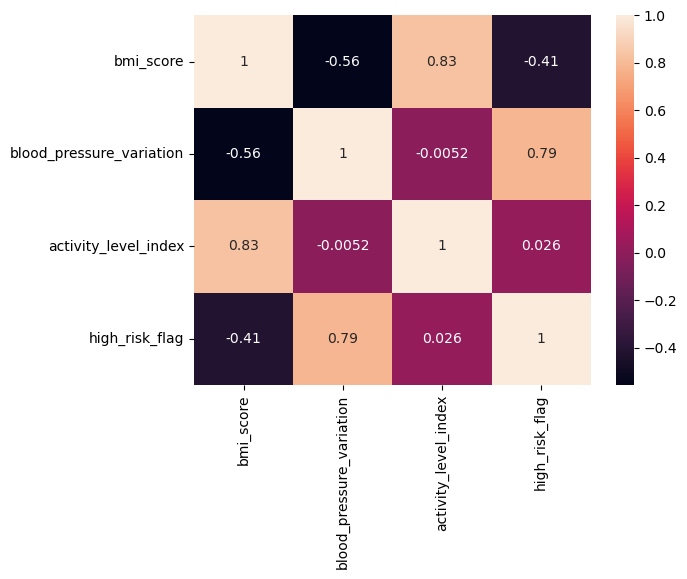

In [33]:
sns.heatmap(df.corr(), annot=True)
plt.show()

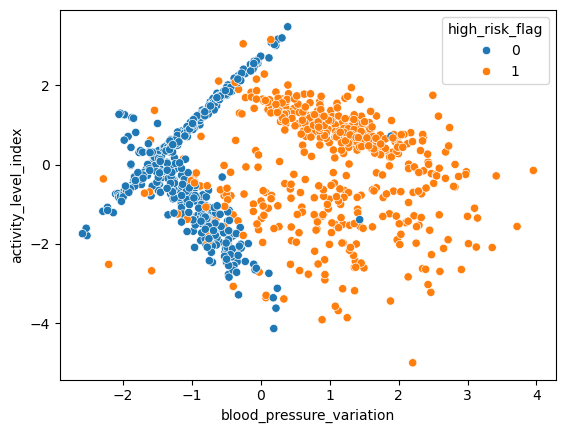

In [34]:
sns.scatterplot(x=df["blood_pressure_variation"], y=df["activity_level_index"], hue=df["high_risk_flag"])
plt.show()

In [35]:
# balance data
df["high_risk_flag"].value_counts()

high_risk_flag
0    502
1    498
Name: count, dtype: int64

In [36]:
# independent & dependent features

X = df.drop("high_risk_flag", axis=1)
y = df["high_risk_flag"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

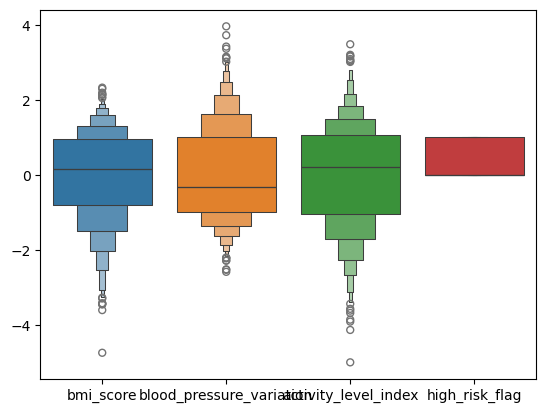

In [37]:
sns.boxenplot(df)
plt.show()

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
from sklearn.neighbors import KNeighborsClassifier

In [40]:
classifier = KNeighborsClassifier(n_neighbors=5, algorithm="auto", weights="uniform")

In [41]:
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.952

[[124   2]
 [ 10 114]]

              precision    recall  f1-score   support

           0       0.93      0.98      0.95       126
           1       0.98      0.92      0.95       124

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



In [44]:
# Key number change
classifier2 = KNeighborsClassifier(n_neighbors=3, algorithm="auto", weights="uniform")
classifier2.fit(X_train, y_train)
y_pred2 = classifier2.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred2))
print()
print(confusion_matrix(y_test, y_pred2))
print()
print(classification_report(y_test, y_pred2))

Accuracy: 0.96

[[125   1]
 [  9 115]]

              precision    recall  f1-score   support

           0       0.93      0.99      0.96       126
           1       0.99      0.93      0.96       124

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250



In [45]:
df_reg = pd.read_csv("12-house_energy_regression.csv")
df_reg.head()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
0,-0.167118,0.146714,-14.996950
1,-0.020902,0.117327,-12.678089
2,0.150419,0.364961,17.775455
3,0.555604,0.089581,6.661465
4,0.058209,-1.142970,-14.195530


In [47]:
# clean data
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   avg_indoor_temp_change        1000 non-null   float64
 1   outdoor_humidity_level        1000 non-null   float64
 2   daily_energy_consumption_kwh  1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB


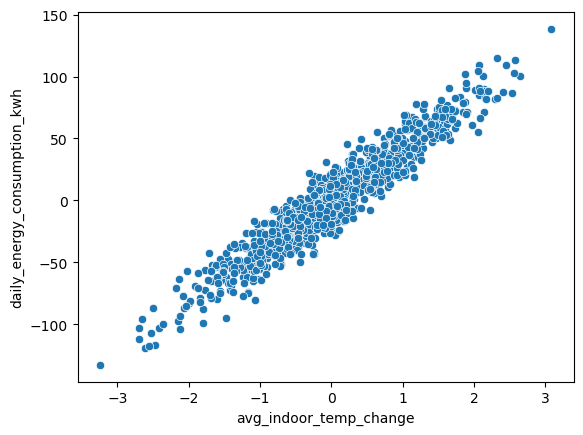

In [49]:
sns.scatterplot(x=df_reg["avg_indoor_temp_change"], y=df_reg["daily_energy_consumption_kwh"])
plt.show()

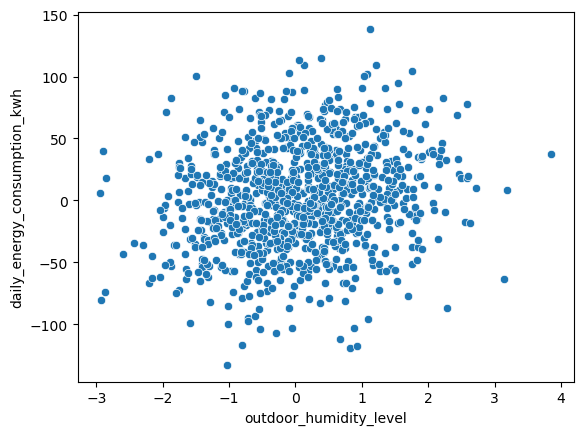

In [50]:
sns.scatterplot(x=df_reg["outdoor_humidity_level"], y=df_reg["daily_energy_consumption_kwh"])
plt.show()

In [52]:
df_reg.corr()["daily_energy_consumption_kwh"].sort_values()

outdoor_humidity_level          0.169557
avg_indoor_temp_change          0.956682
daily_energy_consumption_kwh    1.000000
Name: daily_energy_consumption_kwh, dtype: float64

In [55]:
# target(y) and features(X)

X = df_reg[["outdoor_humidity_level", "avg_indoor_temp_change"]]
y = df_reg["daily_energy_consumption_kwh"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15)

In [56]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
from sklearn.neighbors import KNeighborsRegressor

In [58]:
regressor = KNeighborsRegressor(n_neighbors=5, algorithm="auto")

regressor.fit(X_train_scaled, y_train)

y_pred = regressor.predict(X_test_scaled)

In [62]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("MAE:",mean_absolute_error(y_test, y_pred))
print("MSE:",mean_squared_error(y_test, y_pred))
print("Score:",r2_score(y_test, y_pred))

MAE: 9.42143518926242
MSE: 140.40201685069158
Score: 0.9152685146562609


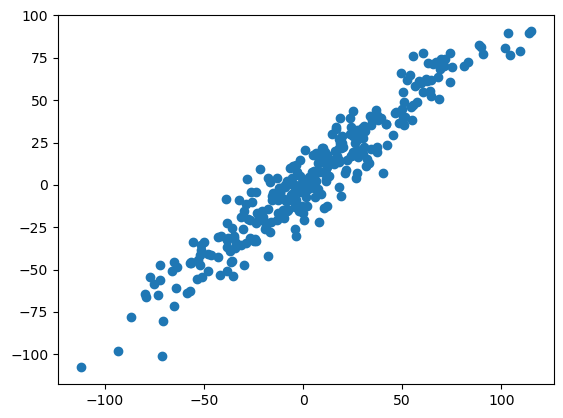

In [65]:
plt.scatter(y_test, y_pred)
plt.show()

MAE: 9.217082380082838
MSE: 136.87578379639785
Score: 0.9173965678784325


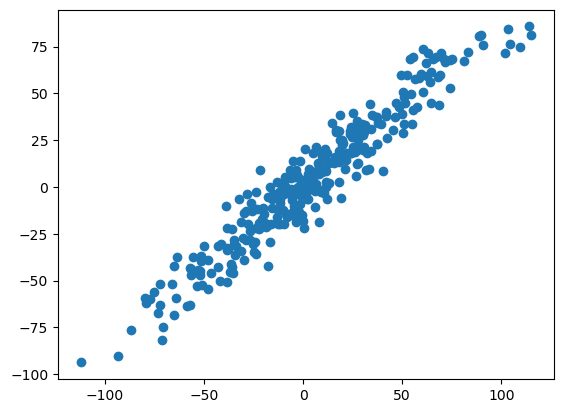

In [66]:
regressor = KNeighborsRegressor(n_neighbors=10, algorithm="auto")

regressor.fit(X_train_scaled, y_train)

y_pred = regressor.predict(X_test_scaled)

print("MAE:",mean_absolute_error(y_test, y_pred))
print("MSE:",mean_squared_error(y_test, y_pred))
print("Score:",r2_score(y_test, y_pred))

plt.scatter(y_test, y_pred)
plt.show()